In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
RANDOM_SEED = 2308
np.random.seed(RANDOM_SEED)

In [3]:
def u_r_Zero_BC(u):
    temp = u*1.0
    temp[0:-1] = u[1:]
    temp[-1] = 0.0 
    return  temp

def u_l_Zero_BC(u):
    temp = u*1.0
    temp[1:] = u[0:-1]
    temp[0] = 0.0 
    return  temp

def Solve_Reaction_Diffusion_Zero_IBC(source,D_coeff=0.01,K_coeff=0.01,x_0=0.0,x_f=1.0,dx=0.01,t_f=1.0,dt=0.001,n_save=10):
    
    x = np.arange(x_0,x_f+dx,dx)
    t = np.arange(0.0,t_f+dt,dt) 
    u = source*0.0
    # u = np.full_like(source, 0.2)
    u_fd = u[1:-1]
    u_save = []
    t_save = []
    for i in range(len(t)):
        u_sol =  x*0.0
        u_sol[1:-1] = u_fd
        if i%n_save==0:
            u_save.append(u_sol)
            t_save.append(t[i])
        u_r = u_r_Zero_BC(u_fd)
        u_l = u_l_Zero_BC(u_fd)
        u_fd = u_fd + ((D_coeff*(u_r + u_l - 2*u_fd))/dx**2 + K_coeff*(u_l/2.0 + u_r/2.0)**2 + source[1:-1] )*dt
    u_save = np.array(u_save)
    t_save = np.array(t_save)
    
    return x, t_save, u_save

def generate_random_A(n,Order):
    
    coeff = np.random.normal(0,1,(n,Order))
    
    return coeff

def random_function(x,A):
    f = 0.0 
    for i in range(1,len(A)+1):
        f = f +  A[i-1]*np.sin(i*x*np.pi) 
    return f

def input_function_random(x,A):

    f = random_function(x,A)

    return f

def tile_array(x,N):
    
    return np.tile(x,(N,1))



/tmp/ipykernel_30/2290894873.py:20: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')
/tmp/ipykernel_30/2290894873.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


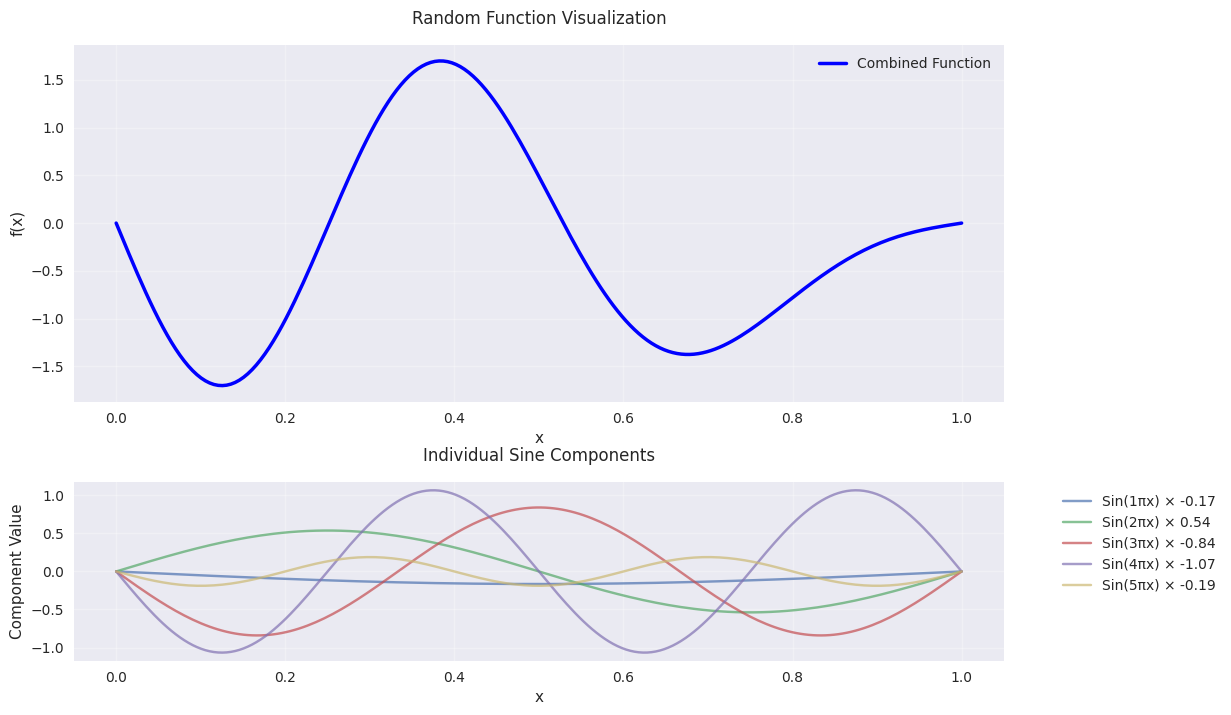


Function Analysis:
-----------------
Number of terms: 5
Coefficients:
  Sin(1πx) coefficient: -0.1653
  Sin(2πx) coefficient: 0.5380
  Sin(3πx) coefficient: -0.8411
  Sin(4πx) coefficient: -1.0671
  Sin(5πx) coefficient: -0.1886

Function Statistics:
  Maximum value: 1.6972
  Minimum value: -1.7012
  Mean value: -0.3061
  Standard deviation: 1.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

def plot_random_function(x, A, show_components=False):
    """
    Plot the random function and optionally its component sine waves.
    
    Parameters:
    -----------
    x : numpy.ndarray
        x-coordinates for plotting
    A : numpy.ndarray
        Array of coefficients for the sine waves
    show_components : bool, optional
        If True, shows individual sine wave components
    """
    # Set style
    plt.style.use('seaborn')
    
    if show_components:
        # Create figure with subplots
        fig = plt.figure(figsize=(12, 8))
        gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.3)
        
        # Main plot
        ax1 = fig.add_subplot(gs[0])
        f = input_function_random(x, A)
        ax1.plot(x, f, 'b-', linewidth=2.5, label='Combined Function')
        ax1.set_title('Random Function Visualization', fontsize=12, pad=15)
        ax1.set_xlabel('x')
        ax1.set_ylabel('f(x)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Components plot
        ax2 = fig.add_subplot(gs[1])
        for i in range(len(A)):
            component = A[i] * np.sin((i + 1) * x * np.pi)
            ax2.plot(x, component, label=f'Sin({i+1}πx) × {A[i]:.2f}', alpha=0.7)
        ax2.set_title('Individual Sine Components', fontsize=12, pad=15)
        ax2.set_xlabel('x')
        ax2.set_ylabel('Component Value')
        ax2.grid(True, alpha=0.3)
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        
    else:
        # Single plot
        plt.figure(figsize=(10, 6))
        f = input_function_random(x, A)
        plt.plot(x, f, 'b-', linewidth=2.5)
        plt.title('Random Function Visualization', fontsize=12, pad=15)
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_and_plot_function(n_terms=5, n_points=200):
    """
    Generate, analyze and plot a random function with specified parameters.
    
    Parameters:
    -----------
    n_terms : int, optional
        Number of sine terms to use
    n_points : int, optional
        Number of points for x-axis discretization
    """
    # Generate x values and coefficients
    x = np.linspace(0, 1, n_points)
    A = generate_random_A(n_terms, 1).flatten()
    
    # Plot the function
    plot_random_function(x, A, show_components=True)
    
    # Print analysis
    print("\nFunction Analysis:")
    print("-----------------")
    print(f"Number of terms: {n_terms}")
    print("Coefficients:")
    for i, coef in enumerate(A):
        print(f"  Sin({i+1}πx) coefficient: {coef:.4f}")
    
    # Calculate some basic statistics
    f = input_function_random(x, A)
    print(f"\nFunction Statistics:")
    print(f"  Maximum value: {np.max(f):.4f}")
    print(f"  Minimum value: {np.min(f):.4f}")
    print(f"  Mean value: {np.mean(f):.4f}")
    print(f"  Standard deviation: {np.std(f):.4f}")



# Generate and plot the function
analyze_and_plot_function(n_terms=5, n_points=200)

In [5]:
f_samples = 20
D_samples = 500
K_samples = 1
train_samples = f_samples * D_samples * K_samples # number of train samples
train_points = 300 # number of solution points
test_samples = 3 # number of test samples
change_train_points = False # if True then change solution points for each samples else keep fixed

In [6]:
D_coeff = 0.02 # diffusion coefficient
D_coeff_range = np.linspace(0.01, 0.05, 30)

K_coeff = 0.01 # reaction coefficient
x_0 = 0.0 # initial x
x_f = 1.0 # final x
dx = 0.01 # spatial resolution 
t_f = 1 # final simulation time
dt = 0.001 # time step
n_save = 10  # save solution at this step
x = np.arange(x_0, x_f + dx, dx)
Order = 5 # number of frequencies in source term basis function


In [7]:
A = generate_random_A(1,Order).flatten() # generate random coefficients for source term basis function 
f_inp = input_function_random(x,A)  
source = f_inp
_ , t, soln = Solve_Reaction_Diffusion_Zero_IBC(source,D_coeff,K_coeff,x_0,x_f,dx,t_f,dt,n_save)
x_eval = x
xx_eval,tt_eval = np.meshgrid(x_eval,t)
x_eval_f ,t_eval_f = xx_eval.flatten()[:,None],tt_eval.flatten()[:,None]
X_eval = np.concatenate((x_eval_f,t_eval_f),axis=1)


In [9]:
def get_axis_label(x,y,axis_interval):
    
    x_ = x.copy()
    y_ = y.copy()

    Nx_grid,Ny_grid = len(x_),len(y_)
    xpoints = list(np.arange(0,Nx_grid,Nx_grid//axis_interval))
    if Nx_grid-1 not in xpoints:
        xpoints.append(Nx_grid-1)

    ypoints = list(np.arange(0,Ny_grid,Ny_grid//axis_interval))
    if Ny_grid-1 not in ypoints:
        ypoints.append(Ny_grid-1)

    x_label_list = list(map( lambda x :round(x,2),[x_[val] for val in xpoints]))
    y_label_list = list(map( lambda x :round(x,2),[y_[val] for val in ypoints]))

    return xpoints, ypoints, x_label_list, y_label_list

xpoints, ypoints, x_label_list, y_label_list = get_axis_label(x,t,4)

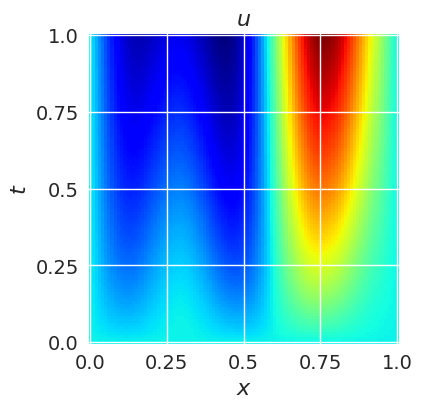

In [10]:
fig, ax1 = plt.subplots(1,1,figsize=(4,5))
im1 = ax1.imshow(soln,cmap='jet',origin='lower')
ax1.set_title(r'$u$' ,fontsize=16)
ax1.set_xticks(xpoints)
ax1.set_xticklabels(x_label_list,fontsize=14)
ax1.set_yticks(ypoints)
ax1.set_yticklabels(y_label_list,fontsize=14)
ax1.set_xlabel(r'$x$',fontsize=16)
ax1.set_ylabel(r'$t$',fontsize=16)
plt.show()

In [14]:
x_sensor =  x.copy() #np.linspace(x_0, x_f, sensor_points)
sensor_points = len(x_sensor)

# A_train = generate_random_A(train_samples,Order) #np.zeros((train_samples,Order))
A_train = generate_random_A(f_samples,Order) #np.zeros((train_samples,Order))


input_branch_train = np.zeros((train_samples,sensor_points))
input_trunk_data_train = np.zeros((train_samples,train_points,2))
target_data_train = np.zeros((train_samples,101,101))
idx_train = np.random.choice(len(X_eval),train_points , replace=False)
D_coeff_data = np.zeros((train_samples,1))
K_coeff_data = np.zeros((train_samples,1))

sample_idx = 0

for i in range(f_samples):
    
    if change_train_points:
        idx_train = np.random.choice(len(X_eval),train_points , replace=False)
        
    A = A_train[i]
    f_input = input_function_random(x,A)
    f_input_sensor = input_function_random(x_sensor,A)
    source = f_input
    for D_coeff in D_coeff_range:
        _ , t, soln = Solve_Reaction_Diffusion_Zero_IBC(source,D_coeff,K_coeff,x_0,x_f,dx,t_f,dt,n_save)
        soln_v = soln.flatten()[:,None]
        X_train = X_eval[idx_train,:]
        soln_train = soln_v[idx_train,:]
        input_trunk_data_train[sample_idx]  = X_train
        target_data_train[sample_idx] = soln
        input_branch_train[sample_idx] = f_input_sensor.reshape(1,-1)
        D_coeff_data[sample_idx] = D_coeff
        K_coeff_data[sample_idx] = K_coeff
        sample_idx += 1


In [15]:
print('trunk train dim: ',input_trunk_data_train.shape)
print('target train dim: ',target_data_train.shape)
print('branch train dim: ',input_branch_train.shape)
print('D_Coeff: ',D_coeff_data.shape)
print('K_Coeff: ',K_coeff_data.shape)

trunk train dim:  (10000, 300, 2)
target train dim:  (10000, 101, 101)
branch train dim:  (10000, 101)
D_Coeff:  (10000, 1)
K_Coeff:  (10000, 1)


In [16]:
import os

def create_train_test_split(trunk_data, target_data, branch_data, D_coeff_data, train_size=14400, random_seed=42):
    """
    Randomly split the data into training and test sets while maintaining corresponding samples.
    
    Returns:
    --------
    dict containing train and test sets for all four arrays
    """
    # Set random seed for reproducibility
    np.random.seed(random_seed)
    
    # Total number of samples
    n_samples = len(trunk_data)
    
    # Generate random indices for train-test split
    indices = np.random.permutation(n_samples)
    train_indices = indices[:train_size]
    test_indices = indices[train_size:]
    
    # Split the data
    train_data = {
        'trunk': trunk_data[train_indices],
        'target': target_data[train_indices],
        'branch': branch_data[train_indices],
        'D_coeff': D_coeff_data[train_indices],
        'K_coeff': K_coeff_data[train_indices]
    }
    
    test_data = {
        'trunk': trunk_data[test_indices],
        'target': target_data[test_indices],
        'branch': branch_data[test_indices],
        'D_coeff': D_coeff_data[test_indices],
        'K_coeff': K_coeff_data[test_indices]
    }
    
    # Print the shapes of resulting arrays
    print("Training set shapes:")
    print(f"Trunk: {train_data['trunk'].shape}")
    print(f"Target: {train_data['target'].shape}")
    print(f"Branch: {train_data['branch'].shape}")
    print(f"D_coeff: {train_data['D_coeff'].shape}")
    print(f"K_coeff: {train_data['K_coeff'].shape}")
    
    print("\nTest set shapes:")
    print(f"Trunk: {test_data['trunk'].shape}")
    print(f"Target: {test_data['target'].shape}")
    print(f"Branch: {test_data['branch'].shape}")
    print(f"D_coeff: {test_data['D_coeff'].shape}")
    print(f"K_coeff: {test_data['K_coeff'].shape}")

    
    return train_data, test_data

def save_split_data(train_data, test_data, save_dir='split_data'):
    """
    Save the train and test data arrays to specified directory.
    
    Parameters:
    -----------
    train_data : dict
        Dictionary containing train arrays for 'trunk', 'target', 'branch', 'D_coeff' and 'K_coeff'
    test_data : dict
        Dictionary containing test arrays for 'trunk', 'target', 'branch', 'D_coeff' and 'K_coeff'
    save_dir : str
        Directory to save the numpy arrays
    """
    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Save training data
    for key in train_data:
        filename = os.path.join(save_dir, f'{key}_train.npy')
        np.save(filename, train_data[key])
        print(f"Saved {filename}, shape: {train_data[key].shape}")
    
    # Save test data
    for key in test_data:
        filename = os.path.join(save_dir, f'{key}_test.npy')
        np.save(filename, test_data[key])
        print(f"Saved {filename}, shape: {test_data[key].shape}")
        
        
train_data, test_data = create_train_test_split(input_trunk_data_train, target_data_train, input_branch_train, D_coeff_data)

save_split_data(train_data, test_data, save_dir='./')

Training set shapes:
Trunk: (10000, 300, 2)
Target: (10000, 101, 101)
Branch: (10000, 101)
D_coeff: (10000, 1)
K_coeff: (10000, 1)

Test set shapes:
Trunk: (0, 300, 2)
Target: (0, 101, 101)
Branch: (0, 101)
D_coeff: (0, 1)
K_coeff: (0, 1)
Saved ./trunk_train.npy, shape: (10000, 300, 2)
Saved ./target_train.npy, shape: (10000, 101, 101)
Saved ./branch_train.npy, shape: (10000, 101)
Saved ./D_coeff_train.npy, shape: (10000, 1)
Saved ./K_coeff_train.npy, shape: (10000, 1)
Saved ./trunk_test.npy, shape: (0, 300, 2)
Saved ./target_test.npy, shape: (0, 101, 101)
Saved ./branch_test.npy, shape: (0, 101)
Saved ./D_coeff_test.npy, shape: (0, 1)
Saved ./K_coeff_test.npy, shape: (0, 1)
